# 05 – Dimensionsreduktion: PCA & UMAP

## Vad handlar det här om?

Tänk dig att du har ett pussel med 35 bitar (våra 35 features/kolumner).  
Det är svårt att rita ett pussel med 35 dimensioner – vi kan ju bara se i 2D eller 3D!

**Dimensionsreduktion** är ett trick där vi pressar ihop all information  
från 35 kolumner till bara 2–3 kolumner – utan att tappa för mycket viktig info.

Vi testar två tekniker:

| Teknik | Vad gör den? | Bra för |
|--------|-------------|---------|
| **PCA** | Hittar de riktningar där datan spretar mest (linjärt) | Förklaringsbarhet, se hur mycket info vi behåller |
| **UMAP** | Hittar kluster och mönster (icke-linjärt, mer flexibelt) | Hitta naturliga grupper i datan |

### Mål med denna notebook
- Visualisera om anställda som slutar (*Attrition = Yes*) bildar egna kluster
- Förstå hur mycket information PCA behåller per komponent
- Jämföra PCA och UMAP visuellt

In [1]:
# ── Standardbibliotek ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Data ───────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisering ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 – aktiverar 3D-stöd
import seaborn as sns

# ── Dimensionsreduktion ────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
import umap

# ── Projektmoduler ─────────────────────────────────────────────────────────────
import sys
sys.path.append("../src")
from data_processing import split_and_scale

# ── Inställningar ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")

print("✅ Alla bibliotek laddade!")

✅ Alla bibliotek laddade!


## Ladda och skala data

Innan vi kör PCA eller UMAP måste vi **skala** våra features.

Varför? Tänk att en kolumn mäter ålder (20–60) och en annan mäter månadslön (1 000–20 000).  
PCA tror då att lönen är *viktigare* bara för att siffrorna är större – men det stämmer inte!

Med **StandardScaler** räknar vi om alla kolumner så att de har:
- Medelvärde = 0
- Standardavvikelse = 1

Nu behandlas alla features rättvist! ⚖️

In [2]:
# Ladda den rensade datan
df = pd.read_csv("../data/attrition_clean.csv")

# Dela upp och skala (scale=True krävs för PCA & UMAP)
X_train, X_test, y_train, y_test, scaler = split_and_scale(df, scale=True)

# Slå ihop train + test för visualisering (vi tränar inget här)
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

print(f"\n📐 Features (skalade): {X_all.shape[1]} kolumner")
print(f"👥 Antal anställda:    {X_all.shape[0]} rader")
print(f"\n🎯 Attrition-fördelning:")
print(y_all.value_counts().rename({0: "Stannar (0)", 1: "Slutar (1)"}))

[data_processing] Split: 1,176 train / 294 test (stratified, test_size=0.2)
[data_processing] Features scaled with StandardScaler

📐 Features (skalade): 44 kolumner
👥 Antal anställda:    1470 rader

🎯 Attrition-fördelning:
Attrition
Stannar (0)    1233
Slutar (1)      237
Name: count, dtype: int64


## PCA – Principal Component Analysis

### Hur funkar PCA?

Tänk att du har en sky av punkter i ett rum med 44 dimensioner.  
PCA hittar den **riktning där punkterna spretar mest** – det är den första komponenten (PC1).  
Sedan hittar den nästa riktning (vinkelrät mot PC1) – det är PC2. Och så vidare.

Varje komponent fångar en del av den totala variansen (= informationen) i datan.

### Vad tittar vi på?
1. **Scree plot** – hur mycket information behåller vi per komponent?
2. **2D scatter** – kan vi se att "slutar"-gruppen bildar egna kluster?
3. **3D scatter** – samma sak men med en dimension till

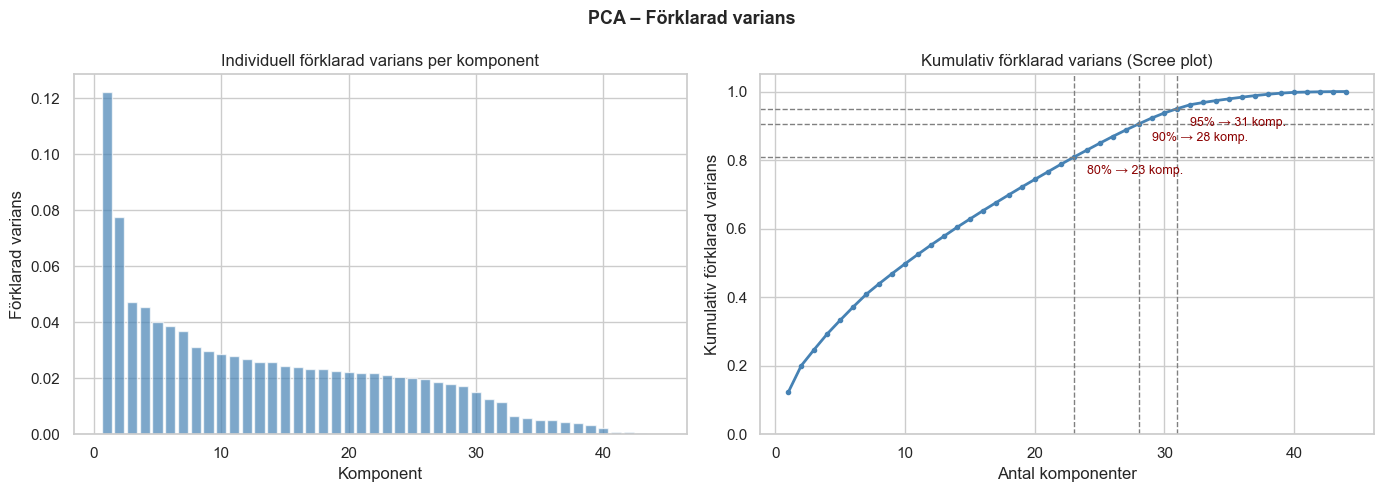


📊 Komponenter som krävs:
  80% förklarad varians → 23 komponenter
  90% förklarad varians → 28 komponenter
  95% förklarad varians → 31 komponenter


In [3]:
# Kör PCA med alla komponenter
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_all)

# Kumulativ förklarad varians
explained      = pca_full.explained_variance_ratio_
cumulative     = np.cumsum(explained)

# Hitta hur många komponenter som krävs för 80, 90 och 95 %
thresholds = {
    "80%": np.argmax(cumulative >= 0.80) + 1,
    "90%": np.argmax(cumulative >= 0.90) + 1,
    "95%": np.argmax(cumulative >= 0.95) + 1,
}

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vänster: individuell förklarad varians (staplar)
axes[0].bar(range(1, len(explained) + 1), explained, color="steelblue", alpha=0.7)
axes[0].set_xlabel("Komponent")
axes[0].set_ylabel("Förklarad varians")
axes[0].set_title("Individuell förklarad varians per komponent")

# Höger: kumulativ kurva
axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker="o", markersize=3,
             color="steelblue", lw=2)

for label, n in thresholds.items():
    axes[1].axhline(y=cumulative[n - 1], color="grey", linestyle="--", lw=1)
    axes[1].axvline(x=n, color="grey", linestyle="--", lw=1)
    axes[1].annotate(f"{label} → {n} komp.",
                     xy=(n, cumulative[n - 1]),
                     xytext=(n + 1, cumulative[n - 1] - 0.05),
                     fontsize=9, color="darkred")

axes[1].set_xlabel("Antal komponenter")
axes[1].set_ylabel("Kumulativ förklarad varians")
axes[1].set_title("Kumulativ förklarad varians (Scree plot)")
axes[1].set_ylim(0, 1.05)

plt.suptitle("PCA – Förklarad varians", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Komponenter som krävs:")
for label, n in thresholds.items():
    print(f"  {label} förklarad varians → {n} komponenter")

## 🔍 Vad ser vi?

### Individuell varians (vänster)
- Den **första komponenten (PC1)** förklarar ~12 % av all information – störst av alla
- Sedan sjunker det stadigt – ingen enskild komponent dominerar kraftigt
- Det finns **inget tydligt "knä"** i kurvan, vilket betyder att informationen  
  är ganska jämnt spridd över många features

### Kumulativ varians (höger)
| Tröskel | Komponenter som krävs | Reducering |
|---------|----------------------|------------|
| 80 %    | 23 av 44             | −48 %      |
| 90 %    | 28 av 44             | −36 %      |
| 95 %    | 31 av 44             | −30 %      |

### Vad betyder det för oss?
- Datan har **ingen dominant struktur** – informationen är utspridd
- För att visualisera används bara **2–3 komponenter** (ca 20 % av variansen)  
  – vi *tappar* alltså mycket information i 2D-plotten
- Det är helt normalt för HR-data med många one-hot-kodade kolumner 🙂

## PCA – 2D-visualisering

Nu pressar vi ihop alla 44 kolumner till **bara 2** – så att vi kan rita en vanlig graf!

Varje punkt = en anställd.  
- 🔵 **Blå punkt** = stannar kvar  
- 🔴 **Röd punkt** = slutar (Attrition = Yes)

Om de röda punkterna samlas i ett eget hörn → PCA har hittat ett mönster!  
Om allt är blandat → PCA lyckas inte separera grupperna i 2D.

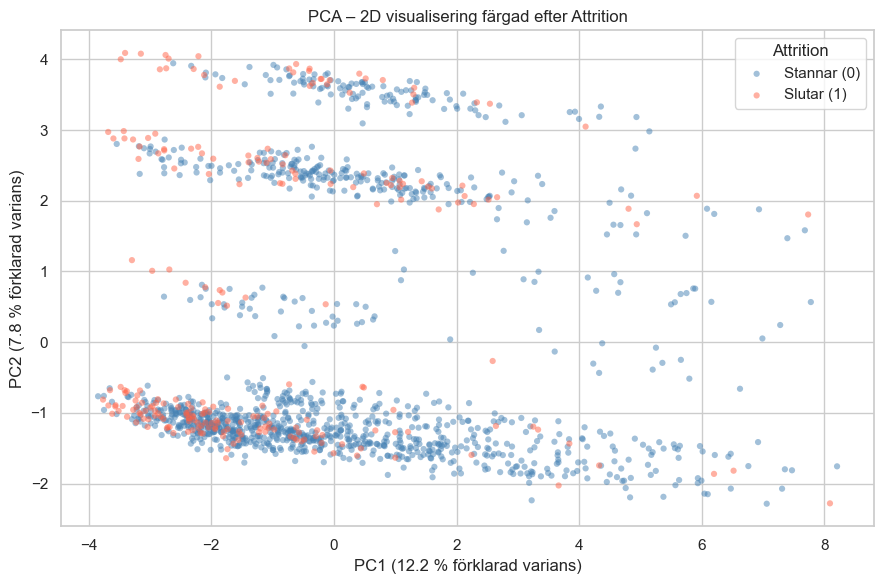


📐 PC1 förklarar: 12.2 %
📐 PC2 förklarar: 7.8 %
📐 Totalt (2D):   20.0 %


In [4]:
# Reducera till 2 komponenter för visualisering
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_all)

# Förklarad varians per komponent
var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

colors = {0: "steelblue", 1: "tomato"}
labels = {0: "Stannar (0)", 1: "Slutar (1)"}

for cls in [0, 1]:
    mask = y_all == cls
    ax.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        c=colors[cls],
        label=labels[cls],
        alpha=0.5,
        s=20,
        edgecolors="none",
    )

ax.set_xlabel(f"PC1 ({var1:.1f} % förklarad varians)")
ax.set_ylabel(f"PC2 ({var2:.1f} % förklarad varians)")
ax.set_title("PCA – 2D visualisering färgad efter Attrition")
ax.legend(title="Attrition", loc="upper right")

plt.tight_layout()
plt.savefig("../outputs/figures/pca_2d.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📐 PC1 förklarar: {var1:.1f} %")
print(f"📐 PC2 förklarar: {var2:.1f} %")
print(f"📐 Totalt (2D):   {var1 + var2:.1f} %")

## 🔍 Vad ser vi?

### Förklarad varians
- PC1 + PC2 förklarar bara **20 % av all information** – 80 % är alltså borta i denna vy
- Det betyder att 2D-plotten är en ganska **suddig bild** av verkligheten

### Separation mellan grupperna
- De röda punkterna (slutar) och blå (stannar) är **kraftigt överlappande**
- Det finns **inget tydligt kluster** av enbart röda punkter
- PCA lyckas alltså **inte separera** de två grupperna i 2D

### Den intressanta strukturen
- Vi ser två "band" – ett övre och ett nedre – vilket troligtvis speglar  
  någon kategorisk feature (t.ex. avdelning eller jobbroll) snarare än Attrition
- De röda punkterna verkar vara **något mer koncentrerade till vänster** (låga PC1-värden)

### Slutsats
PCA är ett linjärt verktyg – det kan bara hitta **raka mönster**.  
Attrition verkar bero på **icke-linjära samband** mellan features.  
Därför testar vi härnäst UMAP, som är mycket bättre på att hitta komplexa mönster! 🚀

## PCA – 3D-visualisering

Vi lägger till en tredje komponent (PC3) för att se om det hjälper!

Tre dimensioner fångar totalt ~28 % av informationen – lite mer än 2D.

Tänk på det som att vrida och vända på ett föremål för att se det från  
fler håll – kanske hittar vi ett bättre perspektiv där de röda punkterna  
separerar sig från de blå? 🔄

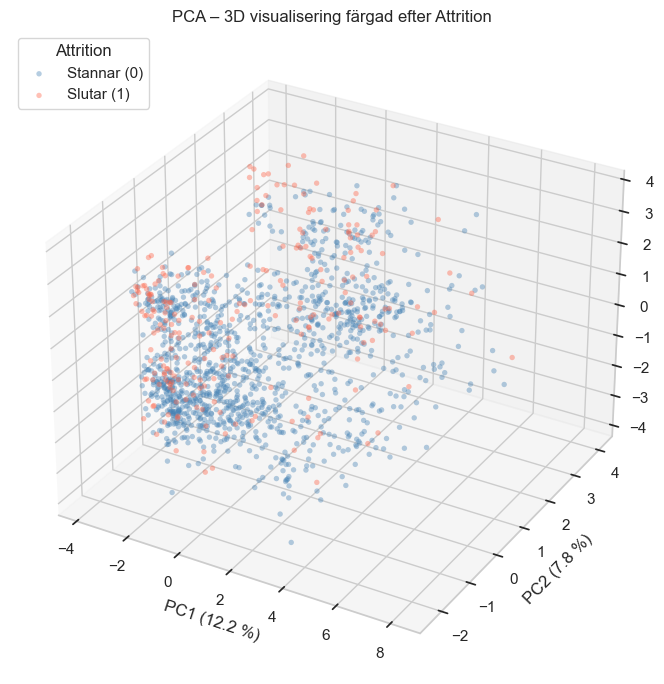


📐 PC1 förklarar: 12.2 %
📐 PC2 förklarar: 7.8 %
📐 PC3 förklarar: 4.7 %
📐 Totalt (3D):   24.7 %


In [5]:
# Reducera till 3 komponenter
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X_all)

# Förklarad varians per komponent
var1 = pca_3d.explained_variance_ratio_[0] * 100
var2 = pca_3d.explained_variance_ratio_[1] * 100
var3 = pca_3d.explained_variance_ratio_[2] * 100

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")

colors = {0: "steelblue", 1: "tomato"}
labels = {0: "Stannar (0)", 1: "Slutar (1)"}

for cls in [0, 1]:
    mask = y_all == cls
    ax.scatter(
        X_pca_3d[mask, 0],
        X_pca_3d[mask, 1],
        X_pca_3d[mask, 2],
        c=colors[cls],
        label=labels[cls],
        alpha=0.4,
        s=15,
        edgecolors="none",
    )

ax.set_xlabel(f"PC1 ({var1:.1f} %)")
ax.set_ylabel(f"PC2 ({var2:.1f} %)")
ax.set_zlabel(f"PC3 ({var3:.1f} %)")
ax.set_title("PCA – 3D visualisering färgad efter Attrition")
ax.legend(title="Attrition", loc="upper left")

plt.tight_layout()
plt.savefig("../outputs/figures/pca_3d.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📐 PC1 förklarar: {var1:.1f} %")
print(f"📐 PC2 förklarar: {var2:.1f} %")
print(f"📐 PC3 förklarar: {var3:.1f} %")
print(f"📐 Totalt (3D):   {var1 + var2 + var3:.1f} %")

## 🔍 Vad ser vi?

### Förklarad varians
- PC1 + PC2 + PC3 förklarar **24.7 %** – bara lite mer än 2D-versionen (20 %)
- PC3 tillförde alltså bara **4.7 % extra information** – ganska lite

### Separation mellan grupperna
- Även i 3D är de röda och blå punkterna **kraftigt överlappande**
- Ingen tydlig separation går att se från något håll
- Den extra dimensionen hjälpte **inte nämnvärt**

### Slutsats
PCA bekräftar det vi misstänkte:
- Attrition går **inte att separera linjärt** – inte ens i 3D
- Strukturen i datan är för komplex för PCA

Dags att testa **UMAP** – ett mycket kraftfullare verktyg för  
att hitta icke-linjära mönster! 🚀

## UMAP – Uniform Manifold Approximation and Projection

### Hur funkar UMAP?

PCA letar efter **raka linjer** i datan.  
UMAP är smartare – det letar efter **kluster och kurvor**!

Tänk dig att du har en hopvikt filt med punkter på.  
PCA försöker platta ut filten med ett strykjärn (linjärt).  
UMAP försöker istället **veckla ut filten varsamt** och bevara vilka punkter  
som är nära varandra – även om vägen dit är krokig! 🧶

### Viktiga parametrar vi ställer in

| Parameter | Värde | Betyder |
|-----------|-------|---------|
| `n_neighbors` | 30 | Hur många grannar varje punkt tittar på |
| `min_dist` | 0.1 | Hur tätt punkter får packas ihop |
| `n_components` | 2 | Vi vill ha 2D som output |
| `random_state` | 42 | Reproducerbart resultat |

> **Tips:** Fler grannar (`n_neighbors`) → mer global struktur.  
> Färre grannar → mer lokala kluster.

⏳ Kör UMAP – detta tar några sekunder...
✅ UMAP klar!


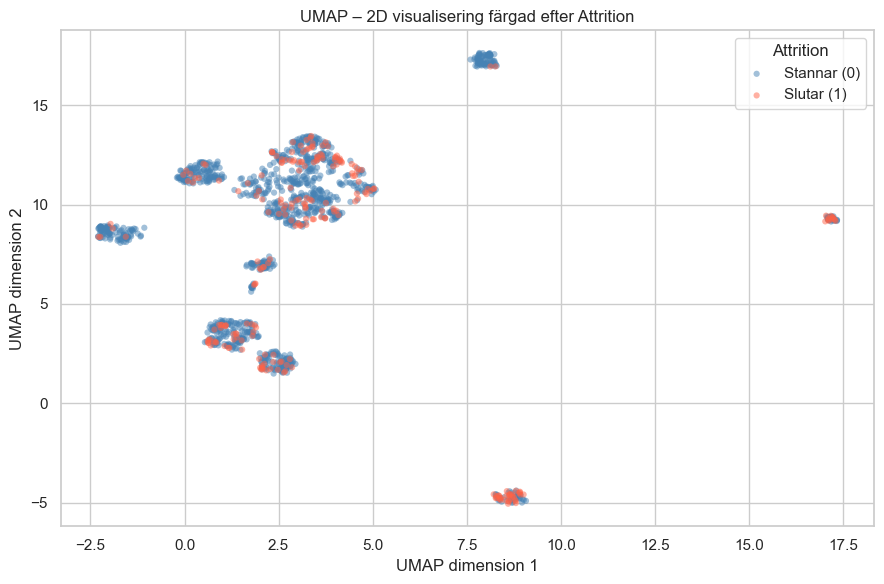


👥 Totalt visualiserade punkter: 1470


In [6]:
# Kör UMAP
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=RANDOM_STATE,
)

print("⏳ Kör UMAP – detta tar några sekunder...")
X_umap = reducer.fit_transform(X_all)
print("✅ UMAP klar!")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

colors = {0: "steelblue", 1: "tomato"}
labels = {0: "Stannar (0)", 1: "Slutar (1)"}

for cls in [0, 1]:
    mask = y_all == cls
    ax.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        c=colors[cls],
        label=labels[cls],
        alpha=0.5,
        s=20,
        edgecolors="none",
    )

ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_title("UMAP – 2D visualisering färgad efter Attrition")
ax.legend(title="Attrition", loc="upper right")

plt.tight_layout()
plt.savefig("../outputs/figures/umap_2d.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n👥 Totalt visualiserade punkter: {X_umap.shape[0]}")

## 🔍 Vad ser vi?

### UMAP hittade tydliga kluster!
Till skillnad från PCA ser vi nu **separata öar** av punkter – UMAP har  
lyckats hitta naturlig struktur i datan! 🏝️

### De intressantaste observationerna

| Kluster | Vad ser vi? |
|---------|-------------|
| **Höger (ca x=17)** | Nästan **enbart röda** punkter – ett nästan rent Attrition-kluster! |
| **Nedre mitten (ca y=−5)** | Också **mestadels röda** – ytterligare en riskgrupp |
| **Övre mitten (ca y=17)** | Nästan **enbart blå** – låg attrition-risk |
| **Vänster (ca x=−2.5)** | Mestadels blå med få röda inblandade |
| **Stora centrala klustret** | Blandat – här är det svårast att skilja grupperna åt |

### Vad betyder klustrena?
UMAP grupperar anställda som **liknar varandra** på samma ställe.  
Att vissa kluster är nästan helt röda tyder på att det finns  
**specifika profiler** av anställda med hög risk att sluta –  
troligtvis kombinationer av jobbroll, ålder, övertid och lön.

### PCA vs UMAP – en första jämförelse
- **PCA**: allt blandat, ingen separation synlig
- **UMAP**: tydliga kluster, vissa nästan helt röda ✅

UMAP avslöjar alltså mönster som PCA **helt missade**!  
Härnäst jämför vi dem sida vid sida. 🚀

## PCA vs UMAP – Jämförelse sida vid sida

Nu lägger vi de två metoderna bredvid varandra för att tydligt se skillnaden.

### Vad är skillnaden egentligen?

| | PCA | UMAP |
|---|---|---|
| **Typ** | Linjär | Icke-linjär |
| **Bevarar** | Global varians | Lokala grannskapsstrukturer |
| **Snabb?** | ✅ Mycket snabb | 🟡 Långsammare |
| **Tolkningsbar?** | ✅ Ja (% varians) | ❌ Axlarna betyder inget |
| **Hittar kluster?** | ❌ Sällan | ✅ Ofta |

> **Kom ihåg:** UMAP-axlarnas värden betyder ingenting i sig –  
> det är bara **avståndet mellan punkterna** som spelar roll!

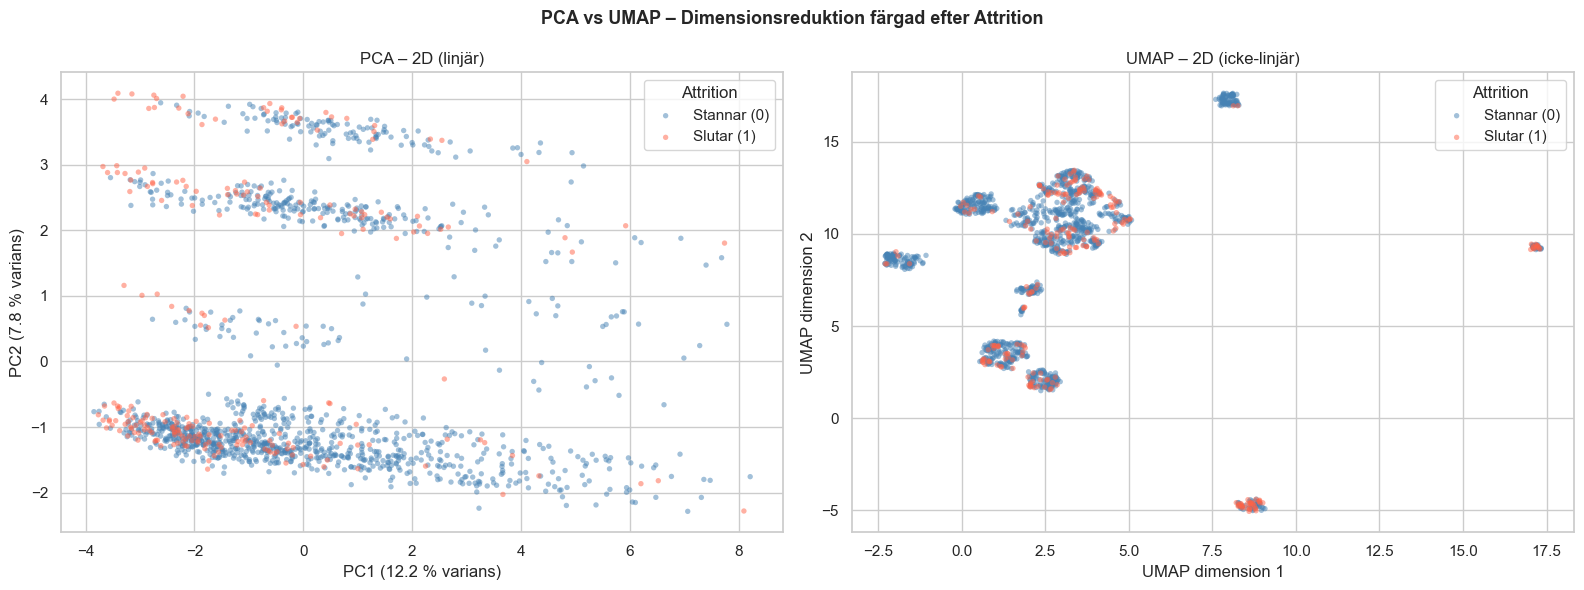

In [7]:
# ── Plot: PCA vs UMAP sida vid sida ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {0: "steelblue", 1: "tomato"}
labels = {0: "Stannar (0)", 1: "Slutar (1)"}

# ── Vänster: PCA 2D ────────────────────────────────────────────────────────────
for cls in [0, 1]:
    mask = y_all == cls
    axes[0].scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        c=colors[cls],
        label=labels[cls],
        alpha=0.5,
        s=15,
        edgecolors="none",
    )
axes[0].set_xlabel(f"PC1 ({var1:.1f} % varians)")
axes[0].set_ylabel(f"PC2 ({var2:.1f} % varians)")
axes[0].set_title("PCA – 2D (linjär)")
axes[0].legend(title="Attrition")

# ── Höger: UMAP 2D ─────────────────────────────────────────────────────────────
for cls in [0, 1]:
    mask = y_all == cls
    axes[1].scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        c=colors[cls],
        label=labels[cls],
        alpha=0.5,
        s=15,
        edgecolors="none",
    )
axes[1].set_xlabel("UMAP dimension 1")
axes[1].set_ylabel("UMAP dimension 2")
axes[1].set_title("UMAP – 2D (icke-linjär)")
axes[1].legend(title="Attrition")

plt.suptitle("PCA vs UMAP – Dimensionsreduktion färgad efter Attrition",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/pca_vs_umap.png", dpi=150, bbox_inches="tight")
plt.show()

## 🔍 Vad ser vi?

### PCA (vänster) – linjär
- Punkterna bildar **utdragna band** utan tydlig separation
- Röda och blå punkter är **helt blandade** – PCA kan inte skilja dem åt
- 2D fångar bara 20 % av informationen – mycket går förlorat

### UMAP (höger) – icke-linjär
- Tydliga **separata öar** av punkter – UMAP hittar verklig struktur!
- Två kluster är **nästan helt röda** (hög attrition-risk)
- Ett kluster uppe i mitten är **nästan helt blått** (låg risk)
- Klustrena speglar troligen **jobbroller eller avdelningar** kombinerat  
  med faktorer som övertid och lön

### Varför är detta viktigt?
UMAP visar att det **finns** naturliga grupper av anställda med hög risk  
att sluta – men gränsen mellan grupperna är **icke-linjär**.

Det förklarar varför ett enkelt beslutsträd (notebook 02) hade svårt,  
medan **XGBoost** (notebook 04) – som hanterar icke-linjära mönster –  
presterade bäst! Allt hänger ihop. 🧩

### Sammanfattning
| Metod | Separation | Användning |
|-------|-----------|------------|
| PCA   | ❌ Ingen tydlig | Dimensionsreduktion, komprimering |
| UMAP  | ✅ Tydliga kluster | Visualisering, klusteranalys |

## Sammanfattning – Vad har vi lärt oss?

### PCA
- Informationen i datan är **jämnt spridd** över många features – inget tydligt "knä"
- Vi behöver **23 komponenter** för att behålla 80 % av informationen
- I 2D och 3D går det **inte** att separera de som slutar från de som stannar
- PCA är ett bra verktyg för komprimering men **inte** för att visualisera Attrition

### UMAP
- Hittar **tydliga kluster** som PCA helt missade
- Vissa kluster innehåller nästan **enbart anställda som slutar**
- Bekräftar att Attrition beror på **icke-linjära mönster** i datan

### Kopplingen till våra modeller
| Notebook | Modell | Klarar icke-linjära mönster? |
|----------|--------|------------------------------|
| 02 | Decision Tree | 🟡 Delvis |
| 03 | Random Forest | ✅ Ja |
| 04 | XGBoost | ✅ Ja – bäst! |

> UMAP-visualiseringen ger oss en intuitiv förståelse för **varför  
> XGBoost presterade bäst** – datan kräver ett kraftfullt,  
> icke-linjärt verktyg för att hitta rätt mönster. 🏆

### Nästa steg
I **notebook 06** samlar vi ihop alla resultat från samtliga modeller  
och berättar den fullständiga historien om Employee Attrition. 📖